## Assign spots to masks and quantify transcriptional activity

In [1]:
from ioMicro import *

#### Plot brightness distribution for each color channel

In [113]:
# Create dictionary of brightness values for each color channel from dataset
brightness_750 = {}
brightness_Cy5 = {}
brightness_Cy3 = {}

for fov in tqdm(range(225)):
    for hybe in range(1,8):
        for icol in range(3):
            spots = np.load(f'Z:\Zane_20CRE\\7_17_2024__T7_20CRE\\analysis\\Conv_zscan__{fov:03d}--D{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
            h = spots[:,-1].tolist()
            if icol == 0:
                brightness_750[f'{fov:03d}-H{hybe}-{icol}'] = h
            
            if icol == 1:
                brightness_Cy5[f'{fov:03d}-H{hybe}-{icol}'] = h
                
            if icol == 2:
                brightness_Cy3[f'{fov:03d}-H{hybe}-{icol}'] = h

100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [04:36<00:00,  1.23s/it]


In [114]:
from itertools import chain

# Combine brightness values across FOVs and rounds of imaging
h_750 = [brightness_750[i] for i in brightness_750]
h_750_total = list(chain.from_iterable(h_750))

h_Cy5 = [brightness_Cy5[i] for i in brightness_Cy5]
h_Cy5_total = list(chain.from_iterable(h_Cy5))

h_Cy3 = [brightness_Cy3[i] for i in brightness_Cy3]
h_Cy3_total = list(chain.from_iterable(h_Cy3))

Text(0.5, 0, 'Brightness')

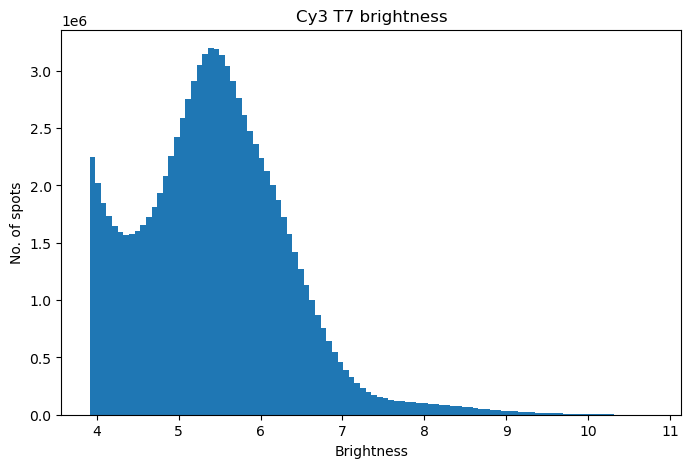

In [127]:
# Plot distribution of all brightness values for each color channel
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(np.log(h_Cy5_total), bins=100)
ax.set_title('Cy3 T7 brightness')
ax.set_ylabel('No. of spots')
ax.set_xlabel('Brightness')

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\Spot_thresholding\240814_Cy3_T7_total_brightness.pdf')

In [119]:
np.exp(6.6)

735.0951892419727

#### Fine tune brightness thresholds using raw image data

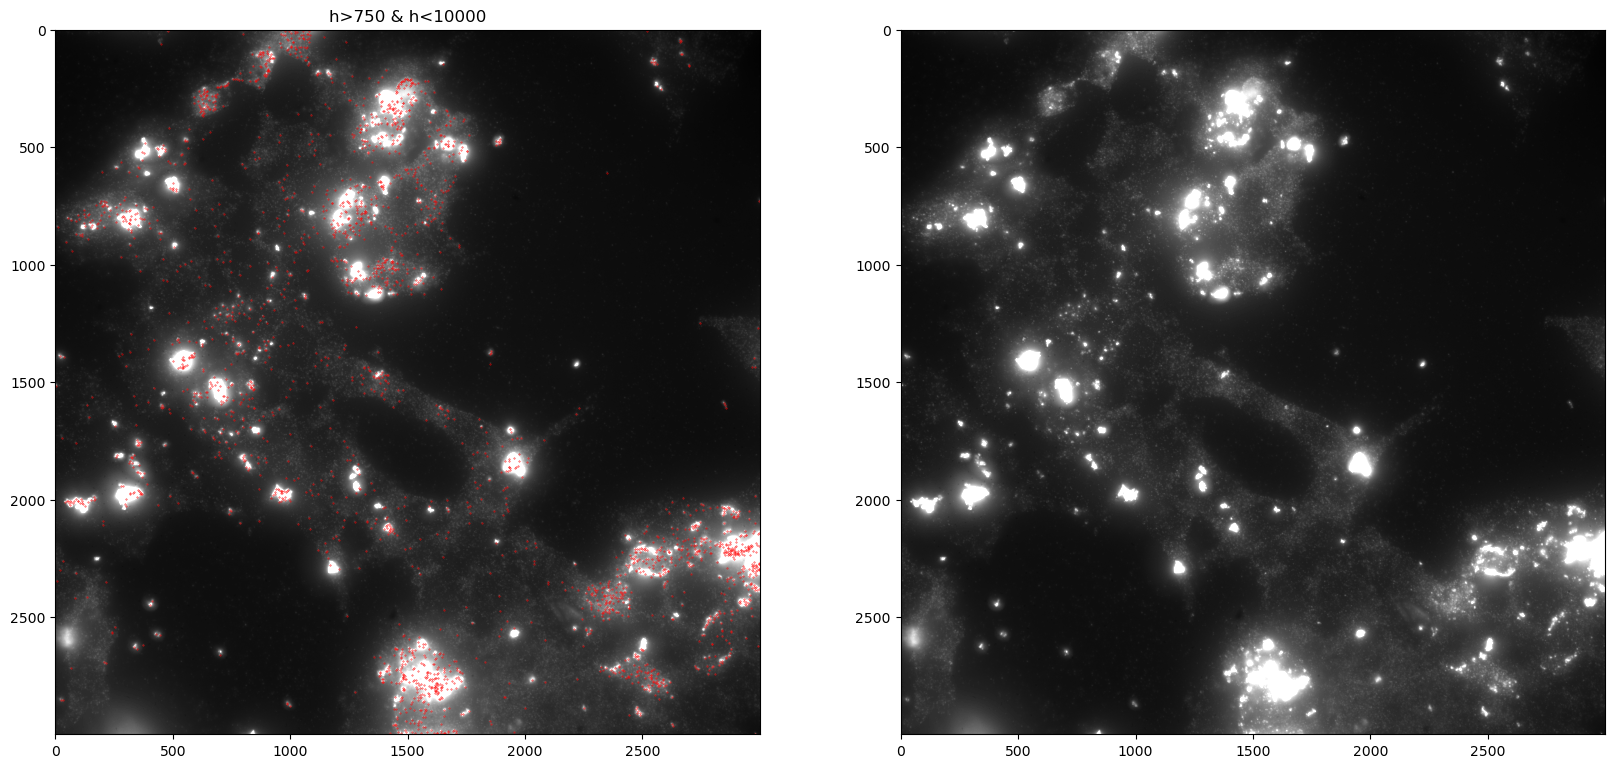

In [154]:
import matplotlib.pyplot as plt

CRE = np.load(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__020--D1_fits_icol0.npz')['Xh']
h = CRE[:,7]
keep = np.where((h>750) & (h<5000))
CRE_ = CRE[keep]

img = read_im(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\HGFP\Conv_zscan__020.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=8500, cmap='gray')
axs[0].scatter(CRE_[:,2], CRE_[:,1], s=0.1, c='r')
axs[0].set_title('h>750 & h<10000')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=8500, cmap='gray')
# plt.gca().invert_yaxis()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\Spot_thresholding\240819_T720.pdf')1

Text(0.5, 1.0, 'h>1100 & h<10000')

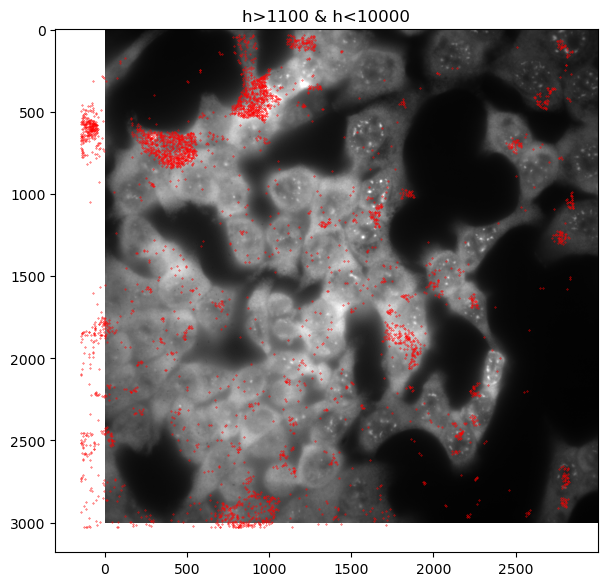

In [185]:
import matplotlib.pyplot as plt

CRE = np.load(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__055--H1_fits_icol0.npz')['Xh']
CRE[:,:3]-=tzxy
h = CRE[:,7]
keep = np.where((h>200) & (h<5000))
CRE_ = CRE[keep]

img = read_im(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\HGFP\Conv_zscan__055.zarr')

fig, axs = plt.subplots(figsize=(7,7))

axs.imshow(img[3,12,:,:], vmax=12000, cmap='gray')
axs.scatter(CRE_[:,2], CRE_[:,1], s=0.1, c='r')
axs.set_title('h>1100 & h<10000')

# axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=8500, cmap='gray')
# plt.gca().invert_yaxis()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\Spot_thresholding\240819_T720.pdf')1

#### Create dict for spots across all hybes and FOVs using universal brightness thresholds

In [8]:
np.arange(1,8)

array([1, 2, 3, 4, 5, 6, 7])

In [2]:
# Make a yuge dict for all CRE spots across FOVs.
# 
# Can use universal brightness thresholds for each laser channel, which are
# determined using the spot brightness distribution across all hybes.

CRE_counts = {}

for fov in tqdm(range(225)):
    for hybe in range(1,8):
        for icol in range(3):
            spots = np.load(f'Z:\\Zane_20CRE\\7_17_2024__T7_20CRE\\analysis\\Conv_zscan__{fov:03d}--D{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
            # correct the drift for spots as they're loaded in
            drifts = np.load(f'Z:\\Zane_20CRE\\7_17_2024__T7_20CRE\\drifts_polyA\\Conv_zscan__{fov:03d}_drift.pkl', allow_pickle=True)
            drift = drifts[f'D{hybe:01d}'][0]
            spots[:,:3]-=drift
            h = spots[:,-1]
            if icol == 0:
                keep = np.where((h>1100) & (h<5000))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-D{hybe}-{icol}'] = spots_
            
            if icol == 1:
                keep = np.where((h>750) & (h<5000))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-D{hybe}-{icol}'] = spots_
                
            if icol == 2:
                keep = np.where((h>750) & (h<5000))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-D{hybe}-{icol}'] = spots_


100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [04:50<00:00,  1.29s/it]


#### Convert keys from CRE_counts into the actual CRE names

In [3]:
# make list of CRE names and filter the converted dict keys into a new dict, fov_counts

CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020')

fov_filter = [f'{fov:03d}-D1-0', f'{fov:03d}-D1-1', f'{fov:03d}-D1-2', f'{fov:03d}-D2-0', f'{fov:03d}-D2-1', f'{fov:03d}-D2-2', f'{fov:03d}-D3-0', f'{fov:03d}-D3-1', f'{fov:03d}-D3-2', f'{fov:03d}-D4-0',
              f'{fov:03d}-D4-1', f'{fov:03d}-D4-2', f'{fov:03d}-D5-0', f'{fov:03d}-D5-1', f'{fov:03d}-D5-2', f'{fov:03d}-D6-0', f'{fov:03d}-D6-1', f'{fov:03d}-D6-2', f'{fov:03d}-D7-0', f'{fov:03d}-D7-1']

filterByKey = lambda keys: {ccre_conversion[x[3:]] : CRE_counts[x] for x in keys}

ccre_conversion = {channel_id[3:] : ccre for channel_id, ccre in zip(fov_filter, CREs)}

fov_counts = []

for fov in tqdm(range(225)):
    fov_counts.append(filterByKey(fov_filter))

100%|████████████████████████████████████████████████████████████████████████████| 225/225 [00:00<00:00, 112481.33it/s]


#### Create a cell by gene matrix for all spots using the appropriate segmentation masks

In [4]:
# Assign spots for each CRE to masks generated from Cellpose and combine into a pandas dataframe

import pandas as pd
import numpy as np

masked_spots = []
all_cbg_T7 = []

for fov in tqdm(range(225)):
    # load cellpose masks and add (FOV x 1000) to the mask values to distinguish them from other FOVs
    seg_mask = np.load(f'C:\\Users\\zgibbs\\cellpose\\20CRE_T7_July_2024\\20CRE_T7_July_2024_seg\\polyA\\Conv_zscan__{fov:03d}_seg.npy', allow_pickle=True)[()]
    mask_id = fov * 1000 
    seg_mask['masks'] = seg_mask['masks'] + mask_id 

    # specify the appropriate FOV for spots
    spots = fov_counts[fov]
    # filter spots to remove those outside the image dimensions following drift correction
    filtered_spots = {key: coords[(coords[:, 2] <= 2999) & (coords[:, 2] > 0) & (coords[:, 1] <= 2999) & (coords[:, 1] > 0), :] for key, coords in spots.items()}
    
    # round the x,y coordinates for decoded spots and assign to the masks from cellpose
    spot_masks = []
    for key in filtered_spots.keys():
        filtered_spots[key][:,2] = np.around(filtered_spots[key][:,2])
        filtered_spots[key][:,1] = np.around(filtered_spots[key][:,1])
        masks = seg_mask['masks'][np.around(filtered_spots[key][:,1]).astype(int), np.around(filtered_spots[key][:,2]).astype(int)]
        spot_masks += [np.array([masks, np.array([key] * (filtered_spots[key].shape[0])), np.around(filtered_spots[key][:,2]), np.around(filtered_spots[key][:,1])])]
        
    spot_masks = np.hstack(spot_masks).T
    barcodes = pd.DataFrame(data=spot_masks, columns=['masks', 'cre_id', 'x_round', 'y_round'])
    cell_by_gene = pd.crosstab(barcodes.masks, barcodes.cre_id)
    all_cbg_T7.append(cell_by_gene)
    
    # can save the cell-by-gene matrix for each FOV separately:
    # cell_by_gene.to_csv(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/cell_by_gene/cell_by_gene_{fov:03d}.csv')
    
all_cbg_T7 = pd.concat(all_cbg_T7, axis=0)

100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:42<00:00,  5.25it/s]


#### Remove rows from the cell by gene matrix that correspond to empty or "non-cell" masks

In [5]:
non_cells = []

for fov in range(225):
    mask_id = fov * 1000
    non_cells.append(str(mask_id))
    
all_cbg_T7.drop(labels=non_cells, axis=0, inplace = True)

In [6]:
all_cbg_T7

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,CRE011,CRE012,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020
masks,,,,,,,,,,,,,,,,,,,,
1,0,3,3,0,0,0,0,6,0,0,0,0,1,0,0,0,50,1,0,3
10,0,33,36,6,7,6,12,46,2,2,1,5,30,5,5,7,148,20,4,22
11,1,8,9,0,0,2,0,9,1,0,1,1,2,2,1,0,73,3,0,2
12,4,38,27,9,6,6,10,29,4,5,0,7,19,5,5,3,92,17,3,15
13,4,64,74,8,13,16,11,82,12,6,1,16,50,17,14,5,297,49,8,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224058,2,6,3,2,4,1,2,14,1,1,1,1,2,6,1,2,77,3,1,6
224059,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,0,23,0,0,1
224060,6,3,10,6,14,6,5,14,9,6,7,8,8,7,8,5,95,11,8,14


In [147]:
# all_cbg_T7.to_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_all_cbg_T7_v2.csv')

#### Normalize the CRE barcode transcripts per cell using the total transcripts per cell

In [7]:
all_cbg_T7['total transcripts'] = all_cbg_T7.sum(axis=1)

In [8]:
all_cbg_T7['fov'] = pd.cut(all_cbg_T7.index.astype(int), bins = np.arange(0, 226)*1000, right=False)

In [9]:
# all_cbg_T7.to_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_transcripts_unfiltered_cbg_drift_corrected.csv')

In [141]:
all_cbg_T7_clean = all_cbg_T7[all_cbg_T7['total transcripts'] > 0]

In [146]:
all_cbg_T7_clean['total transcripts'].median()

78.0

In [40]:
all_cbg_T7['n_cres_detected'] = (all_cbg_T7 > 0).sum(axis=1) -1 # minus one for total transcripts col 

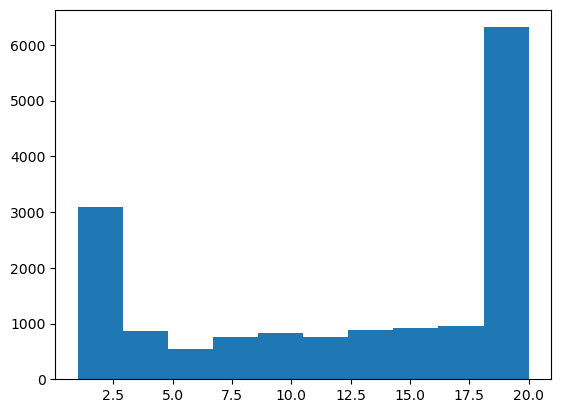

In [75]:
_ = plt.hist(all_cbg_T7['n_cres_detected'])

<Axes: xlabel='masks'>

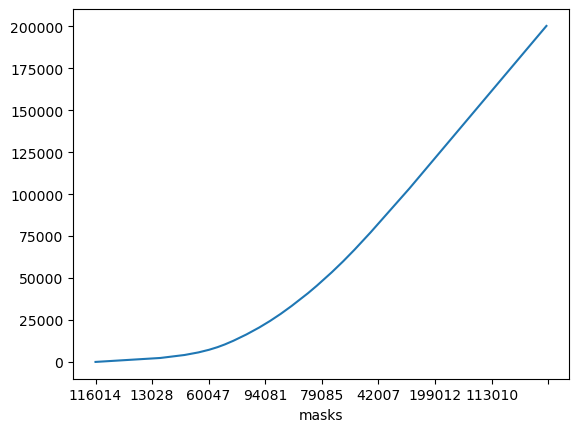

In [73]:
all_cbg_T7['n_cres_detected'].sort_values().cumsum().plot()

In [80]:
dat = all_cbg_T7['n_cres_detected'].sort_values().values

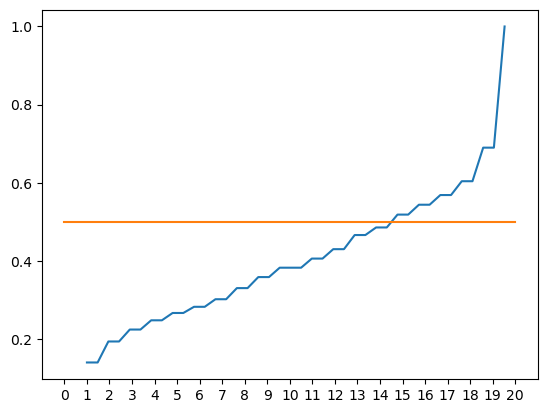

In [91]:
vals, base = np.histogram(dat, bins=40)
sum = np.cumsum(vals) /dat.shape[0]
plt.plot(base[:-1], sum)
_ =plt.xticks(np.arange(21))
plt.plot([0, 20], [.5, .5])

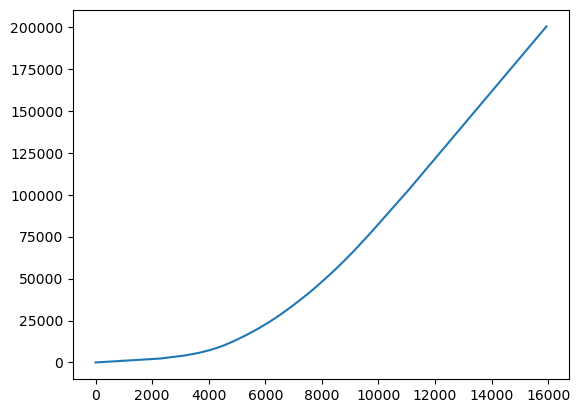

In [74]:
plt.plot(np.cumsum(all_cbg_T7['n_cres_detected'].sort_values().values))

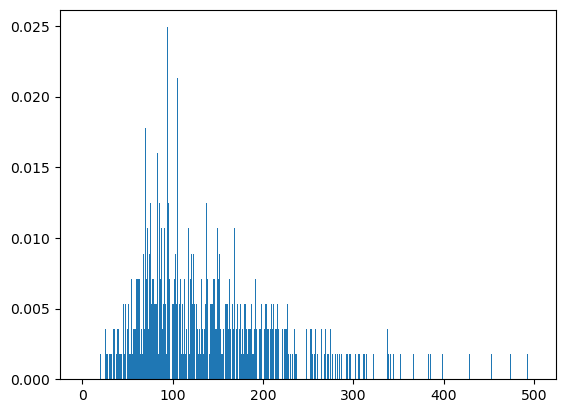

In [95]:
_ = plt.hist(all_cbg_T7_clean.loc[all_cbg_T7.n_cres_detected == 18, 'total transcripts'], bins = np.arange(500), density=True)
# _= plt.xticks(np.arange(100), rotation=90)
# plt.xlim(9, 45)

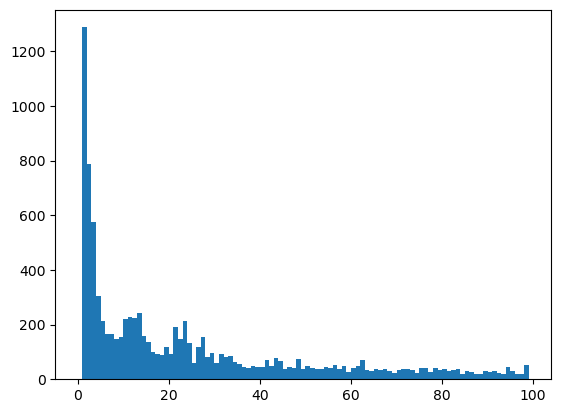

In [39]:
_ = plt.hist(all_cbg_T7_clean['total transcripts'], bins=np.arange(100))

In [191]:
# Normalize to total transcripts per cell after removing "low-count" cells, then perform a log(X + 1) transformation

all_cbg_T7['total transcripts'] = all_cbg_T7.sum(axis=1) # create new column for sum of all transcripts per cell

all_cbg_T7_clean = all_cbg_T7[(all_cbg_T7['total transcripts'] > 15) & (all_cbg_T7['total transcripts'] < all_cbg_T7['total transcripts'].quantile(.9))]

all_cbg_T7_clean['fov'] = pd.cut(all_cbg_T7_clean.index.astype(int), bins = np.arange(0, 226)*1000, right=False)

# all_cbg_norm = all_cbg_clean.div(all_cbg_clean['total transcripts'], axis=0) # divide each CRE count per cell by total transcripts per cell

# all_cbg_norm.drop('total transcripts', axis=1, inplace=True)

# norm2 = np.log(all_cbg_norm + 1) # log(X + 1) normalization

# norm2['fov'] = pd.cut(norm2.index.astype(int), bins = np.linspace(0, 184000, 185), right=False) # add fov info for each cell

############################################################################################# 

# save the cell-by-gene matrices 

all_cbg_T7_clean.to_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_transcripts_cbg_clean_drift_corrected.csv')

# norm2.to_csv('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/cell_by_gene/normalized_cbg.csv')


#############################################################################################
# divide CRE counts by total transcripts per cell
# all_cbg_norm = all_cbg.div(all_cbg['total transcripts'], axis=0)

# drop the total transcripts column from the newly normalized cell by gene matrix (and the original matrix)
# all_cbg_norm.drop('total transcripts', axis=1, inplace=True)
# all_cbg.drop('total transcripts', axis=1, inplace=True)

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_21348\872000516.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_cbg_T7_clean['fov'] = pd.cut(all_cbg_T7_clean.index.astype(int), bins = np.arange(0, 226)*1000, right=False)


In [149]:
all_cbg_T7_clean

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020,total transcripts,fov
masks,,,,,,,,,,,,,,,,,,,,,
1,0,1,4,0,0,0,0,4,0,0,...,1,0,0,0,45,1,0,2,116,"[0, 1000)"
10,0,37,35,6,7,6,13,46,5,3,...,31,5,6,7,152,25,5,24,840,"[0, 1000)"
11,1,11,8,0,0,2,0,5,1,0,...,3,3,0,0,75,3,0,3,232,"[0, 1000)"
12,5,36,32,9,6,6,10,32,6,4,...,21,7,7,3,95,16,3,18,656,"[0, 1000)"
13,5,67,70,8,13,16,12,79,11,6,...,47,16,15,4,287,50,7,66,1592,"[0, 1000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224058,2,8,5,2,4,1,2,15,1,1,...,5,5,1,2,72,3,1,6,276,"[224000, 225000)"
224059,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,21,0,0,1,48,"[224000, 225000)"
224060,5,2,8,6,14,6,4,12,8,5,...,6,6,6,5,86,10,7,13,444,"[224000, 225000)"


C:\Users\zgibbs\AppData\Local\Temp\ipykernel_21348\1616938458.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot([all_cbg_T7_clean.groupby('fov')[i].mean() for i in all_cbg_T7_clean.columns[:-2]], showfliers=False)


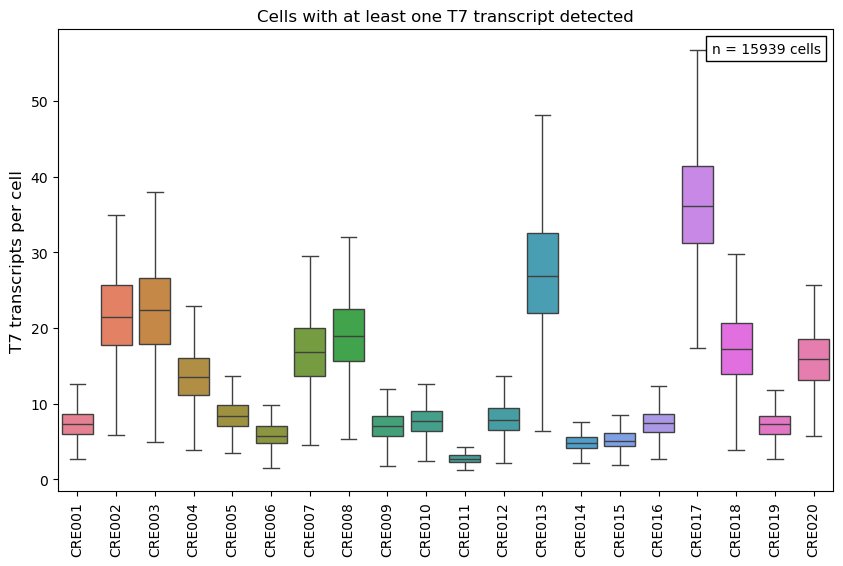

In [14]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot([all_cbg_T7_clean.groupby('fov')[i].mean() for i in all_cbg_T7_clean.columns[:-2]], showfliers=False)
plt.xticks(np.arange(20), all_cbg_T7_clean.columns[:20], rotation=90);
ax.set_ylabel('T7 transcripts per cell', fontsize=12)
ax.set_title('Cells with at least one T7 transcript detected')

numcells = len(all_cbg_T7_clean)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/normalized_mean_CRE_counts_per_FOV_boxplot_231227.png', dpi=600)
plt.show()

In [66]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

#### Add column indicating FOV for each cell

In [52]:
all_cbg_clean['fov'] = pd.cut(all_cbg_clean.index.astype(int), bins = np.linspace(0, 43000, 44), right=False)

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_38656\2040343453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_cbg_clean['fov'] = pd.cut(all_cbg_clean.index.astype(int), bins = np.linspace(0, 43000, 44), right=False)


C:\Users\zgibbs\AppData\Local\Temp\ipykernel_38656\229832221.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot([all_cbg_clean.groupby('fov')[i].mean() for i in all_cbg_clean.columns[:-2]],


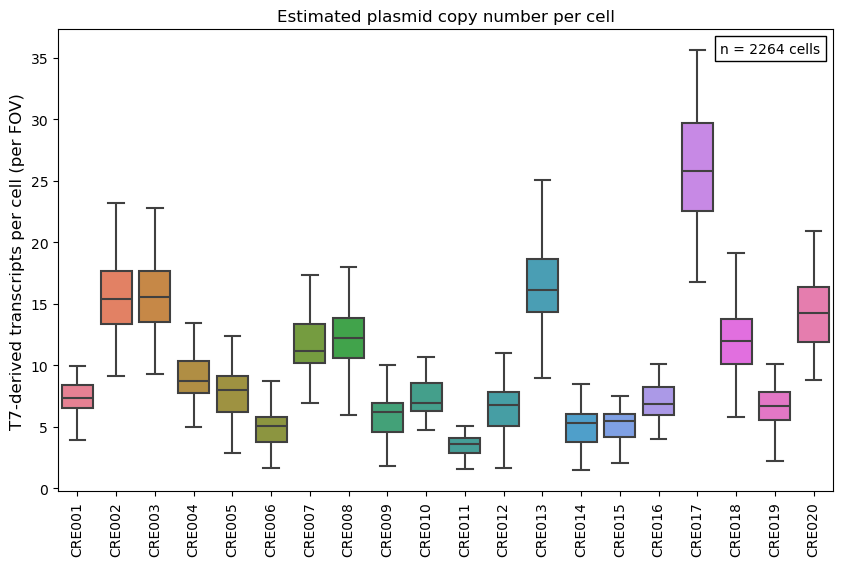

In [82]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot([all_cbg_clean.groupby('fov')[i].mean() for i in all_cbg_clean.columns[:-2]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5)
plt.xticks(np.arange(20), all_cbg_clean.columns[:20], rotation=90);
ax.set_ylabel('T7-derived transcripts per cell (per FOV)', fontsize=12)
ax.set_title('Estimated plasmid copy number per cell')

numcells = len(all_cbg_clean)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_240806.pdf')
plt.show()
plt.show()

#### compare ratios of enhancer transcripts (basis for linear regression analysis)

In [195]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

In [196]:
CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020']

In [22]:
god = all_cbg_clean + 1

In [23]:
all_cbg_clean_ratio = god.div(god['CRE002'], axis=0)

In [24]:
all_cbg_clean_ratio.drop('total transcripts', axis=1, inplace=True)

In [25]:
all_cbg_clean_ratio

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020,blank1,blank2,blank3,blank4
masks,,,,,,,,,,,,,,,,,,,,,
1,0.500000,1.0,0.928571,0.285714,0.357143,0.071429,0.285714,0.142857,0.142857,0.285714,...,0.214286,0.285714,0.071429,0.642857,0.285714,0.500000,0.214286,0.285714,0.142857,0.214286
10,0.730769,1.0,0.615385,0.211538,0.153846,0.192308,0.192308,0.230769,0.173077,0.173077,...,0.115385,0.173077,0.038462,0.250000,0.173077,0.192308,0.115385,0.153846,0.038462,0.096154
103,0.909091,1.0,0.818182,0.636364,0.454545,0.727273,1.000000,0.545455,0.636364,0.727273,...,0.454545,0.636364,0.181818,0.545455,0.636364,0.818182,0.454545,0.636364,0.181818,0.454545
105,0.909091,1.0,1.363636,0.090909,0.090909,0.045455,0.090909,0.045455,0.045455,0.045455,...,0.045455,0.045455,0.045455,0.227273,0.045455,0.181818,0.045455,0.045455,0.045455,0.045455
107,2.000000,1.0,1.500000,1.500000,1.000000,1.500000,0.500000,0.500000,0.500000,1.000000,...,1.000000,0.500000,1.000000,1.500000,0.500000,1.500000,1.000000,0.500000,1.500000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183072,0.826514,1.0,0.734861,0.693944,0.468085,0.255319,0.477905,0.425532,0.191489,0.090016,...,0.121113,0.045827,0.042553,0.705401,0.096563,0.571195,0.083470,0.039280,0.022913,0.060556
183073,0.861862,1.0,0.996997,0.681682,0.741742,0.423423,0.636637,0.717718,0.474474,0.189189,...,0.213213,0.192192,0.093093,0.942943,0.225225,0.903904,0.099099,0.132132,0.021021,0.075075
183074,0.823529,1.0,0.695187,0.566845,0.548128,0.270053,0.475936,0.425134,0.283422,0.131016,...,0.256684,0.080214,0.093583,0.748663,0.050802,0.727273,0.048128,0.045455,0.008021,0.042781


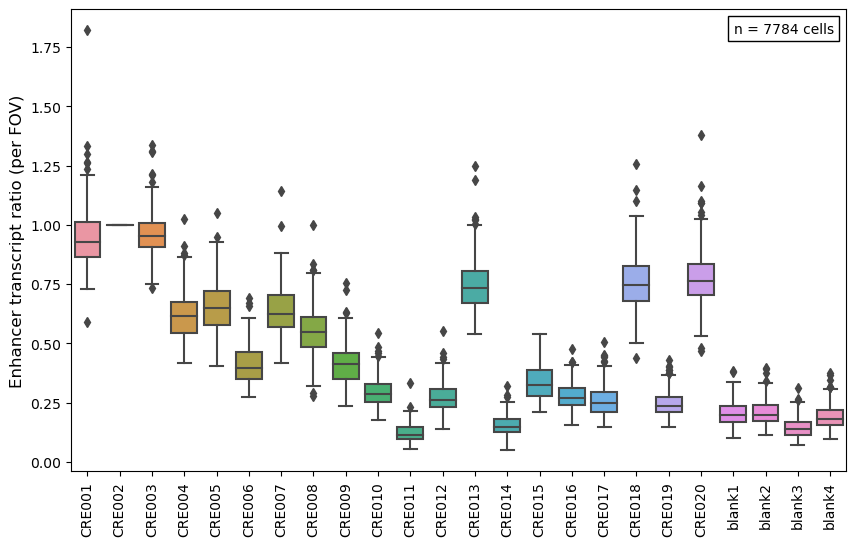

In [27]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

all_cbg_clean_ratio['fov'] = pd.cut(all_cbg_clean_ratio.index.astype(int), bins = np.linspace(0, 184000, 185), right=False) # add fov info for each cell

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot([all_cbg_clean_ratio.groupby('fov')[i].mean() for i in all_cbg_clean_ratio.columns[:-1]])
plt.xticks(np.arange(24), all_cbg_clean_ratio.columns[:-1], rotation=90);
ax.set_ylabel('Enhancer transcript ratio (per FOV)', fontsize=12)
# ax.set_title('CRE counts within cells')

numcells = len(all_cbg_clean_ratio)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/normalized_mean_CRE_counts_per_FOV_boxplot_231227.png', dpi=600)
plt.show()

#### Add column indicating FOV for each cell

In [13]:
# add a new column to cell by gene matrix to indicate fovs
all_cbg_norm['fov'] = pd.cut(all_cbg_norm.index.astype(int), bins = np.linspace(0, 184000, 185), right=False)
all_cbg['fov'] = pd.cut(all_cbg.index.astype(int), bins = np.linspace(0, 184000, 185), right=False)

In [107]:
all_cbg['fov'] = pd.cut(all_cbg.index.astype(int), bins = np.linspace(0, 184000, 185), right=False)

#### Plot filtered spots for each CRE in one FOV

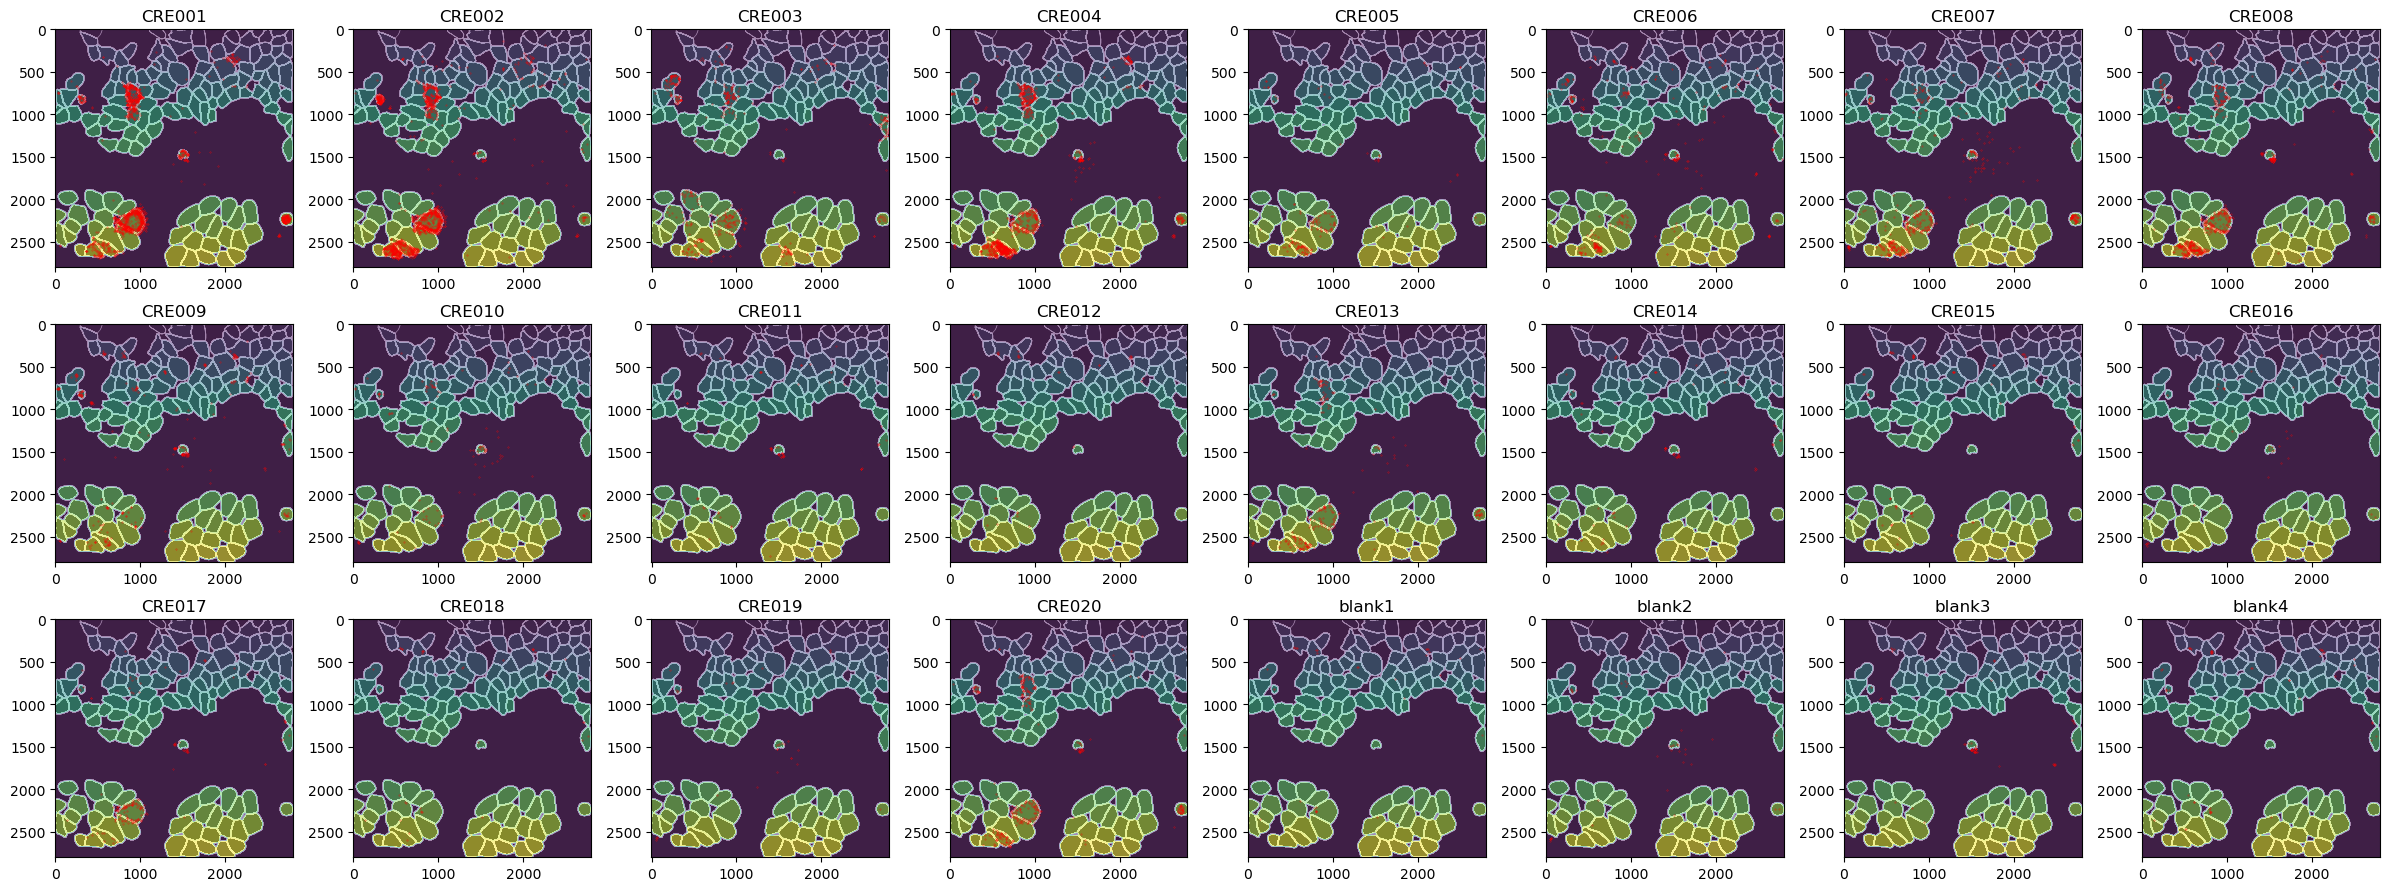

In [15]:
seg_masks = np.load('/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__120_seg.npy', allow_pickle=True)[()]

fig, axs = plt.subplots(3, 8, figsize=(24,9))

axs = axs.flatten()
for key, ax, title in zip(list(CRE_counts.keys())[2880:2904], axs, CREs): # to specify correct starting point for index range, multiply FOV by 24
    ax.imshow(seg_masks['masks'], cmap = 'viridis', alpha=0.8)
    ax.imshow(seg_masks['outlines'], cmap = 'binary_r', alpha=0.4, vmax=0.1)
    ax.scatter(CRE_counts[key][:,2], CRE_counts[key][:,1], s=0.05, c='r')
    ax.set_title(title)
    
plt.tight_layout()
# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/all_CRE_spots_masks_120.png', dpi=450)

In [9]:
import numpy as np
seg_masks = np.load('/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__006_seg.npy', allow_pickle=True)[()]

masks = seg_masks['outlines']

np.save('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/outlines_006.npy', masks)

#### Plot the correlation/relationship between STARR-FISH and STARR-seq data

In [82]:
CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016', 'CRE017', 'CRE018', 'CRE019', 'CRE020']

In [1]:
import pandas as pd

HCT116_oligos = pd.read_csv('/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/HCT116_activating_oligo.csv')

HCT116_oligos

,chr,start,end,lfc,padj
0,chr15,80003305.0,80003495.0,5.601402,3.980000e-124
1,chr15,80003185.0,80003375.0,5.445969,2.070000e-119
2,chr1,244735538.0,244735728.0,5.140302,9.600000e-111
3,chr21,33367286.0,33367476.0,5.099388,1.110000e-109
4,chr22,49384139.0,49384329.0,5.031316,1.690000e-103
...,...,...,...,...,...
1101,YFL009W_196_385,NaN,NaN,0.006862,9.663627e-01
1102,YNL186W_1584_1773,NaN,NaN,0.002139,9.842529e-01
1103,YDR490C_1052_1241,NaN,NaN,0.001636,9.862793e-01
1104,YLR138W_2138_2327,NaN,NaN,-0.001606,9.969921e-01


In [2]:
STARRseq = pd.read_csv('/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAvsDNA.edgeR.csv')
STARRseq

,genes,genes.1,logFC,logCPM,LR,PValue,FDR
0,chr15:80003305-80003495,chr15:80003305-80003495,5.601385,10.262335,931.208886,1.610000e-204,1.200000e-200
1,chr15:80003185-80003375,chr15:80003185-80003375,5.445952,9.878489,1306.822523,3.720000e-286,5.530000e-282
2,chr1:244735538-244735728,chr1:244735538-244735728,5.140283,10.398185,926.936868,1.370000e-203,6.770000e-200
3,chr21:33367286-33367476,chr21:33367286-33367476,5.099376,10.493151,765.505615,1.710000e-168,4.220000e-165
4,chr22:49384139-49384329,chr22:49384139-49384329,5.032509,7.528481,73.439476,1.040000e-17,1.200000e-16
...,...,...,...,...,...,...,...
14847,chr1:161103553-161103743,chr1:161103553-161103743,-6.555657,4.820906,305.059169,2.600000e-68,2.740000e-66
14848,chr3:186999245-186999435,chr3:186999245-186999435,-6.568334,5.249774,685.633001,3.980000e-151,6.570000e-148
14849,chr2:29107347-29107537,chr2:29107347-29107537,-6.679742,4.950180,563.129284,1.750000e-124,9.650000e-122
14850,chr14:102084508-102084698,chr14:102084508-102084698,-6.838318,5.246542,627.747588,1.540000e-138,1.270000e-135


In [10]:
STARRseq['logFC'].loc[test_CREs]

0       5.601385
11      4.373055
4       5.032509
7       4.685353
9       4.493735
137     2.122961
186     1.903971
323     1.588704
515     1.326764
642     1.219671
1100    0.973408
1086    0.983154
1078    0.986207
1073    0.986843
1093    0.978426
1101    0.972873
1102    0.972759
1103    0.972564
1104    0.971994
1105    0.971080
Name: logFC, dtype: float64

In [18]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

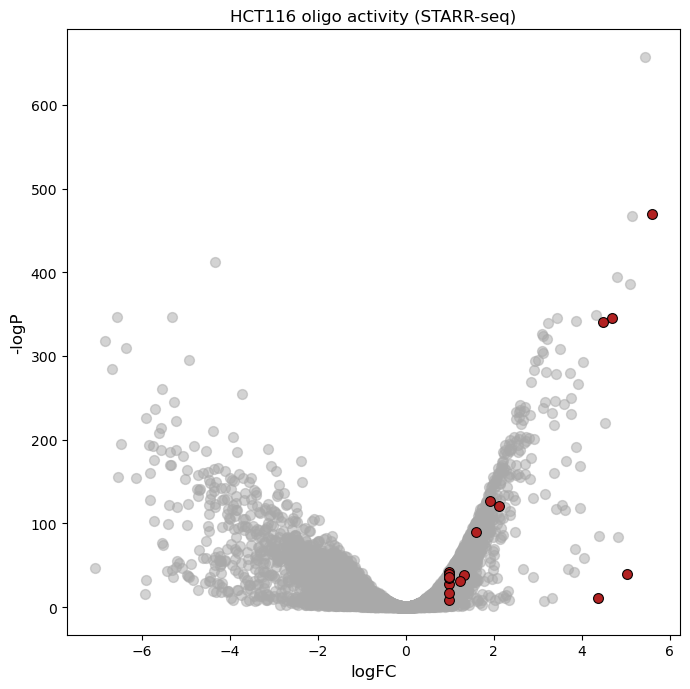

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(STARRseq['logFC'], -np.log(STARRseq['PValue']), s=50, color='darkgrey', alpha=0.5)
ax.scatter(STARRseq['logFC'].loc[test_CREs], -np.log(STARRseq['PValue'].loc[test_CREs]), s=50,
           color='firebrick', edgecolor='k', linewidth=0.75)
ax.set_ylabel('-logP', fontsize=12)
ax.set_xlabel('logFC', fontsize=12)
ax.set_title('HCT116 oligo activity (STARR-seq)')

plt.tight_layout()
# plt.savefig('/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/STARRseq_test_CREs_240227.pdf')
plt.show()

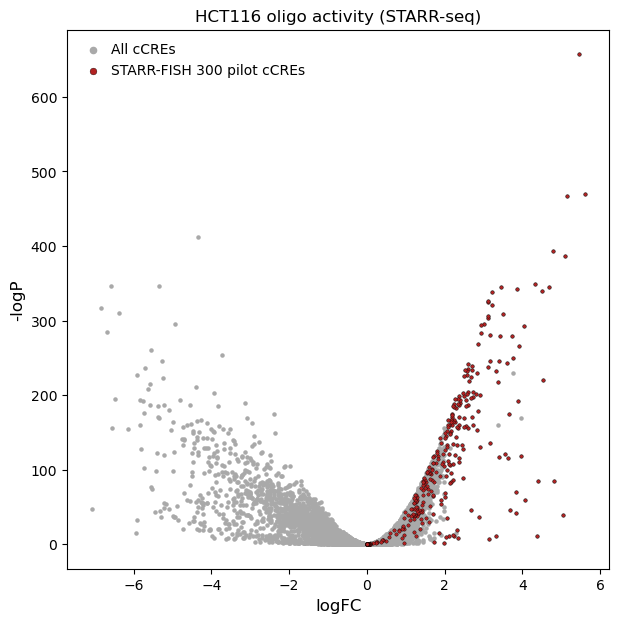

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(STARRseq['logFC'], -np.log(STARRseq['PValue']), s=5, color='darkgrey', label='All cCREs')
ax.scatter(STARRseq['logFC'].loc[idxes_use], -np.log(STARRseq['PValue'].loc[idxes_use]), s=6, color='firebrick', edgecolor='k', linewidth=0.25, label='STARR-FISH 300 pilot cCREs')
ax.set_ylabel('-logP', fontsize=12)
ax.set_xlabel('logFC', fontsize=12)
ax.set_title('HCT116 oligo activity (STARR-seq)')
ax.legend(markerscale=2, frameon=False, handletextpad=0.25)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/STARR-seq_lfc_vs_pval_300_cCREs_pilot.png', dpi=450)

In [7]:
idxes_use = """0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
16
17
18
19
20
21
22
24
25
26
27
28
29
30
31
32
33
34
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
157
161
166
169
171
177
181
183
185
191
194
198
206
210
215
219
223
227
230
235
238
243
247
249
251
255
259
270
274
276
279
285
288
291
303
306
313
321
327
330
337
344
351
355
358
370
374
378
384
389
399
403
406
414
419
421
427
428
430
441
456
463
473
477
501
522
542
548
559
566
571
574
583
587
592
597
600
603
610
616
624
628
635
639
645
652
654
663
664
684
718
753
776
784
826
908
922
1075
1125
1133
1139
1144
1187
1195
1314
1324
1508
1560
1860
2030
2569
2710
3134
3686
3782
4044
4197
4991
5006
5340
5349
5946
6608
6699
6723
6800
6838
6900
6967
7067
7137
7195
7262
7318
7435
7467
7474
7507
7522
7451
7479
7505
7515
7524
7513
7514
7437
7504
7520"""

In [8]:
idxes_use = idxes_use.split('\n')

In [10]:
idxes_use = [int(i) for i in idxes_use]

In [11]:
idxes_use

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 157,
 161,
 166,
 169,
 171,
 177,
 181,
 183,
 185,
 191,
 194,
 198,
 206,
 210,
 215,
 219,
 223,
 227,
 230,
 235,
 238,
 243,
 247,
 249,
 251,
 255,
 259,
 270,
 274,
 276,
 279,
 285,
 288,
 29

In [13]:
test_CREs_2 = [0,1
2
3
4
5
6
7
8
9
10
11
12
13
14
16
17
18
19
20
21
22
24
25
26
27
28
29
30
31
32
33
34
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
157
161
166
169
171
177
181
183
185
191
194
198
206
210
215
219
223
227
230
235
238
243
247
249
251
255
259
270
274
276
279
285
288
291
303
306
313
321
327
330
337
344
351
355
358
370
374
378
384
389
399
403
406
414
419
421
427
428
430
441
456
463
473
477
501
522
542
548
559
566
571
574
583
587
592
597
600
603
610
616
624
628
635
639
645
652
654
663
664
684
718
753
776
784
826
908
922
1075
1125
1133
1139
1144
1187
1195
1314
1324
1508,1560,1860,2030,2569,2710,3134,3686,3782,4044,4197,4991,5006,
5340,5349,5946,6608,6699,6723,6800,6838,6900,6967,7067,7137,7195,7262,7318,7435,7467,7474,7507,7522,7451,7479,7505,7515,7524,7513,7514,7437,7504,7520]

In [17]:
STARRseq

,genes,genes.1,logFC,logCPM,LR,PValue,FDR
0,chr15:80003305-80003495,chr15:80003305-80003495,5.601385,10.262335,931.208886,1.610000e-204,1.200000e-200
1,chr15:80003185-80003375,chr15:80003185-80003375,5.445952,9.878489,1306.822523,3.720000e-286,5.530000e-282
2,chr1:244735538-244735728,chr1:244735538-244735728,5.140283,10.398185,926.936868,1.370000e-203,6.770000e-200
3,chr21:33367286-33367476,chr21:33367286-33367476,5.099376,10.493151,765.505615,1.710000e-168,4.220000e-165
4,chr22:49384139-49384329,chr22:49384139-49384329,5.032509,7.528481,73.439476,1.040000e-17,1.200000e-16
...,...,...,...,...,...,...,...
14847,chr1:161103553-161103743,chr1:161103553-161103743,-6.555657,4.820906,305.059169,2.600000e-68,2.740000e-66
14848,chr3:186999245-186999435,chr3:186999245-186999435,-6.568334,5.249774,685.633001,3.980000e-151,6.570000e-148
14849,chr2:29107347-29107537,chr2:29107347-29107537,-6.679742,4.950180,563.129284,1.750000e-124,9.650000e-122
14850,chr14:102084508-102084698,chr14:102084508-102084698,-6.838318,5.246542,627.747588,1.540000e-138,1.270000e-135


In [11]:
# Indices for the 20 test CREs used in STARR-FISH pilot (last 5 are yeast ORFs)
test_CREs = [0,11,4,7,9,137,186,323,515,642,1100,1086,1078,1073,1093,1101,1102,1103,1104,1105]

len(HCT116_oligos['lfc'].loc[test_CREs])

20

Text(0.5, 1.0, 'HCT116 activating oligos (STARR-seq)')

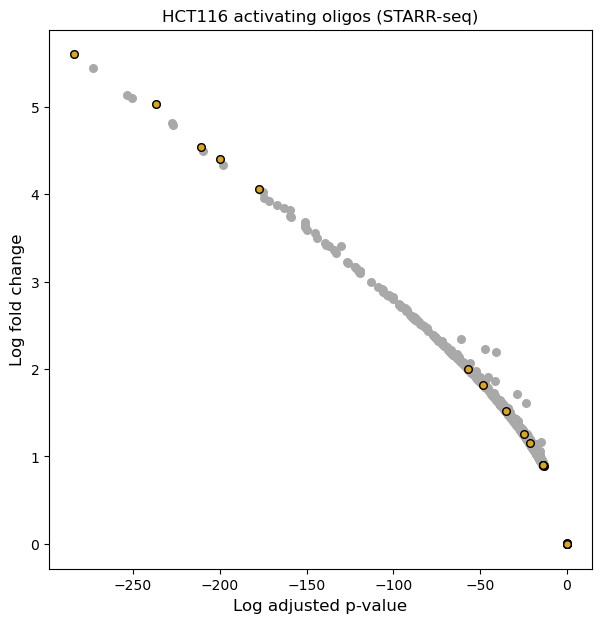

In [19]:
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(np.log(HCT116_oligos['padj']), HCT116_oligos['lfc'], s=30, color='darkgrey')
ax.scatter(np.log(HCT116_oligos['padj'].loc[test_CREs]), HCT116_oligos['lfc'].loc[test_CREs], s=30, color='goldenrod', edgecolor='k', linewidth=1)
ax.set_ylabel('Log fold change', fontsize=12)
ax.set_xlabel('Log adjusted p-value', fontsize=12)
ax.set_title('HCT116 activating oligos (STARR-seq)')

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/STARR-seq_lfc_vs_padj.pdf')

In [20]:
all_cbg[CREs].mean(axis=0)

cre_id
CRE001    4.367435
CRE002    6.752221
CRE003    2.425180
CRE004    3.532343
CRE005    0.258745
CRE006    1.328012
CRE007    2.642421
CRE008    3.051499
CRE009    1.894503
CRE010    0.994725
CRE011    0.287757
CRE012    0.108273
CRE013    0.854525
CRE014    0.494448
CRE015    0.190311
CRE016    0.350916
CRE017    0.631177
CRE018    0.288728
CRE019    0.277068
CRE020    1.469461
dtype: float64

Text(0.5, 0, 'Log fold change (STARR-seq)')

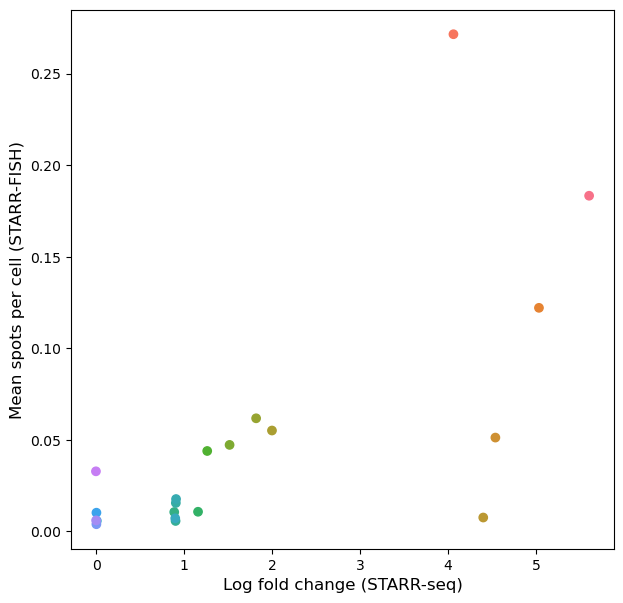

In [21]:
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(HCT116_oligos['lfc'].loc[test_CREs],
           all_cbg_norm[CREs].mean(axis=0),
           c=[colors[i] for i in all_cbg_norm[CREs].columns])
ax.set_ylabel('Mean spots per cell (STARR-FISH)', fontsize=12)
ax.set_xlabel('Log fold change (STARR-seq)', fontsize=12)